In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

In [15]:
df = pd.read_csv('creditcard.csv')
print("Shape:", df.shape)
print("\nClass Distribution:\n", df['Class'].value_counts())

Shape: (284807, 31)

Class Distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


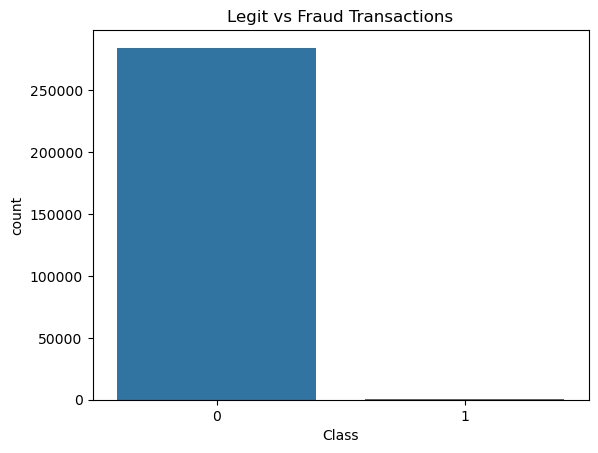


Missing Values: 0


In [16]:
sns.countplot(x='Class', data=df)
plt.title('Legit vs Fraud Transactions')
plt.show()

print("\nMissing Values:", df.isnull().sum().sum())

In [17]:
legit = df[df['Class'] == 0]
fraud = df[df['Class'] == 1]

In [18]:
legit_sample = legit.sample(n=len(fraud), random_state=42)
balanced_df = pd.concat([legit_sample, fraud])

print("\nBalanced Class Distribution:\n", balanced_df['Class'].value_counts())


Balanced Class Distribution:
 Class
0    492
1    492
Name: count, dtype: int64


In [19]:
X = balanced_df.drop('Class', axis=1)
y = balanced_df['Class']

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,
)


In [21]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
model = LogisticRegression()
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [23]:
y_pred = model.predict(X_test)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("ROC AUC Score:", roc_auc_score(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.96      0.93        99
           1       0.96      0.90      0.93        98

    accuracy                           0.93       197
   macro avg       0.93      0.93      0.93       197
weighted avg       0.93      0.93      0.93       197

ROC AUC Score: 0.9287775716347145


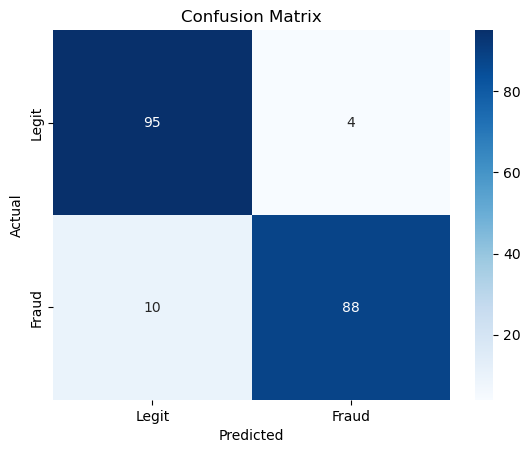

In [24]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()